In [4]:
import pandas as pd
import numpy as np

In [48]:
df = pd.read_csv('C:/Users/suman/OneDrive/Bureau/Internship_Study/GNN_On_OdorPrediction/data/OdorSmiles_Updated.csv', encoding='ISO-8859-1')
X = df.iloc[:, :2]  # 'cas_number' and 'SMILES'
Y = df.iloc[:, 2:]  # Odor descriptors

# Count number of 1s (positive samples) per descriptor
odor_freq = Y.sum().sort_values(ascending=False)

# Select top 40 most frequent descriptors
top_odors = odor_freq.head(30).index
Y_top = Y[top_odors]

# Keep only rows with at least one active label
mask = Y_top.sum(axis=1) > 0
Y_filtered = Y_top[mask]
X_filtered = X[mask]

print(f"Molecules with at least one of top 30 odors: {len(Y_filtered)}")


Molecules with at least one of top 30 odors: 3670


In [49]:
# Score each molecule by number of 1s
Y_filtered['label_count'] = Y_filtered.sum(axis=1)

# Sort by label_count to prioritize multi-label molecules
combined = pd.concat([X_filtered, Y_filtered], axis=1)
combined = combined.sort_values('label_count', ascending=False)


C:\Users\suman\AppData\Local\Temp\ipykernel_7728\142654445.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_filtered['label_count'] = Y_filtered.sum(axis=1)


In [50]:
final_df = combined.drop(columns=['label_count'])
final_df.to_csv('Balanced_OdorSmiles_Top30.csv', index=False)

print("Saved balanced dataset with top 30 descriptors.")


Saved balanced dataset with top 30 descriptors.


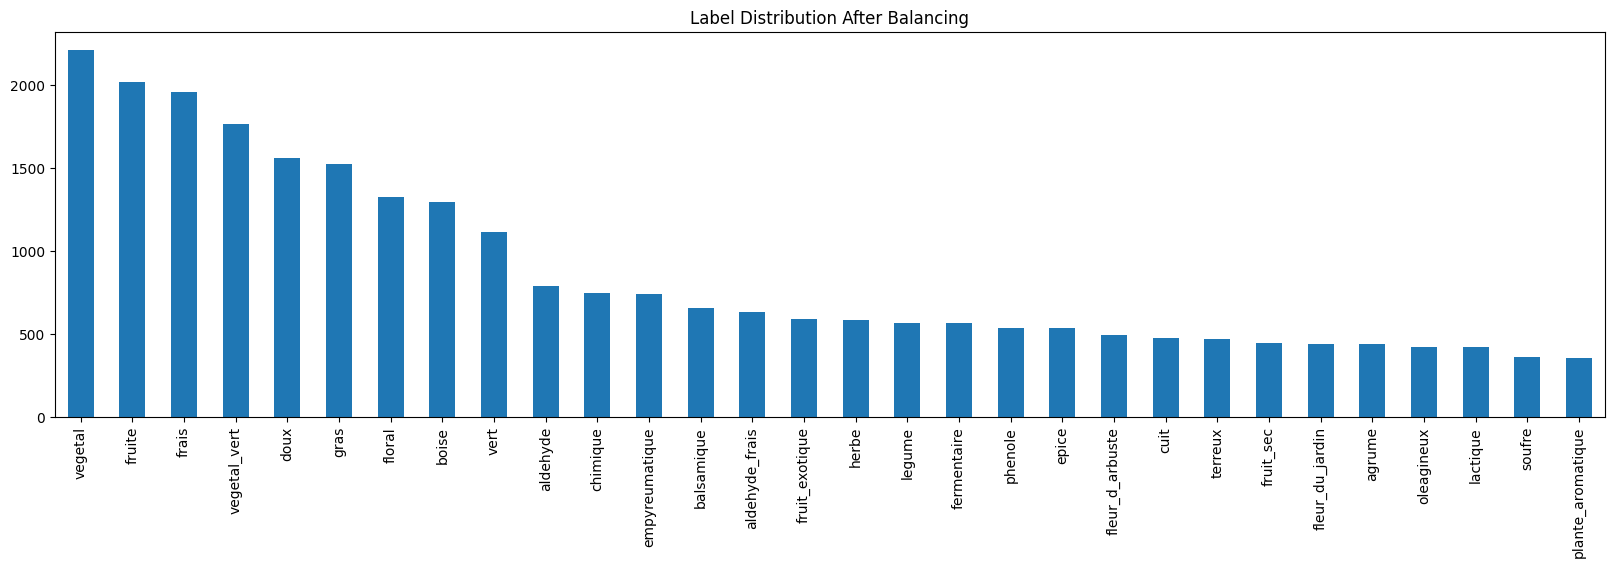

In [51]:
import matplotlib.pyplot as plt

final_Y = final_df.iloc[:, 2:]
label_sums = final_Y.sum().sort_values(ascending=False)
label_sums.plot(kind='bar', figsize=(20, 5), title='Label Distribution After Balancing')
plt.show()


#### Count the number of descriptors removed and molecules removed

In [52]:
# Store original counts
original_descriptor_count = Y.shape[1]
original_molecule_count = Y.shape[0]

# Step 1: Select top 30 most frequent descriptors
odor_freq = Y.sum().sort_values(ascending=False)
top_100_descriptors = odor_freq.head(30).index
Y_top = Y[top_100_descriptors]

# Step 2: Filter molecules that have at least one of these top 100 descriptors
mask = Y_top.sum(axis=1) > 0
Y_filtered = Y_top[mask]
X_filtered = X[mask]

# Calculate removals
removed_descriptors = original_descriptor_count - Y_filtered.shape[1]
removed_molecules = original_molecule_count - Y_filtered.shape[0]

# Print results
print(f"Descriptors removed: {removed_descriptors}")
print(f"Molecules removed: {removed_molecules}")
print(f"Remaining descriptors: {Y_filtered.shape[1]}")
print(f"Remaining molecules: {Y_filtered.shape[0]}")


Descriptors removed: 406
Molecules removed: 18
Remaining descriptors: 30
Remaining molecules: 3670


In [47]:
# Calculate total number of 1's and 0's in the filtered label matrix
total_ones = Y_filtered.values.sum()
total_elements = Y_filtered.size
total_zeros = total_elements - total_ones

print(f"Total 1's (positives): {int(total_ones)}")
print(f"Total 0's (negatives): {int(total_zeros)}")


Total 1's (positives): 32805
Total 0's (negatives): 188295


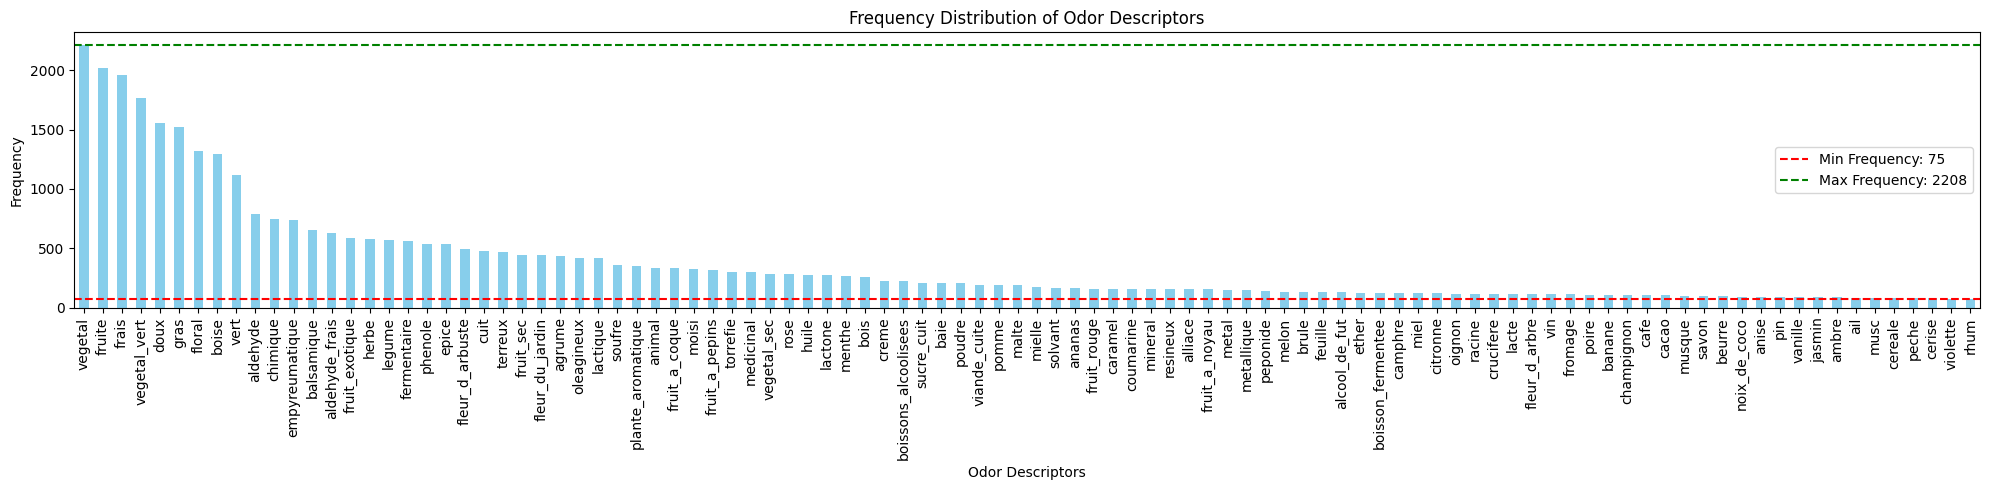

Minimum Frequency: 75
Maximum Frequency: 2208


In [45]:
# Calculate the frequency of each odor descriptor in the filtered label matrix
odor_freq_filtered = Y_filtered.sum(axis=0).sort_values(ascending=False)

# Get the minimum and maximum frequency values
min_freq = odor_freq_filtered.min()
max_freq = odor_freq_filtered.max()

# Plot the frequency distribution of the odors
plt.figure(figsize=(20, 5))
odor_freq_filtered.plot(kind='bar', color='skyblue', title='Frequency Distribution of Odor Descriptors')

# Highlight min and max frequencies
plt.axhline(y=min_freq, color='red', linestyle='--', label=f'Min Frequency: {min_freq}')
plt.axhline(y=max_freq, color='green', linestyle='--', label=f'Max Frequency: {max_freq}')

# Add labels and legend
plt.xlabel('Odor Descriptors')
plt.ylabel('Frequency')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

# Print the min and max frequency values
print(f"Minimum Frequency: {min_freq}")
print(f"Maximum Frequency: {max_freq}")